# Week 4 · Notebook 2 — Variation Operators: Crossover and Mutation for Bits, Reals and Permutations

**Goals**
- Implement the standard variation operators for the three classic representations and state precisely what each
  one preserves: one-point, two-point and uniform crossover with bit-flip mutation; arithmetic, BLX-$\alpha$, SBX,
  polynomial and Gaussian mutation; PMX, OX, cycle crossover and edge recombination.
- Derive and verify **positional bias** of binary crossovers (disruption probability vs defining length).
- Derive the **variance transfer** of BLX-$\alpha$ and SBX and verify it by simulation; verify the SBX spread-factor
  distribution and the polynomial-mutation perturbation distribution against their analytic densities
  (Kolmogorov–Smirnov with `scipy.stats`).
- Check that permutation operators always return valid permutations and measure their **heritability** (fraction
  of child edges inherited from the parents); relate heritability to GA performance on the TSP at an equal budget.

**Prerequisites:** Notebook 1 (the GA loop, tournament selection), Week 1 (TSP, 2-opt neighbourhood).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from scipy import stats
from utils import PALETTE, random_euclidean_tsp, tour_length, held_karp, best_so_far_on_grid

## 1. What a variation operator is

A mutation operator is a Markov kernel $M(y \mid x)$ on the genotype space $G$; a crossover operator is a kernel
$C(z \mid x, y)$. Two properties organise the whole design space:

* **Respect / heritability** (Radcliffe 1991): what the parents share, the child should share; the child should be
  assembled from *meaningful units* of the parents (bits, coordinates, adjacency edges).
* **Locality of the offspring distribution**: how far (in the metric of the representation) children land from
  their parents — the operator's *step-size*. Exploration = broad offspring distributions; exploitation = narrow.

Crossover is the one mechanism that distinguishes a GA from a population of parallel hill-climbers: it samples
*between* existing solutions. Whether that helps depends on whether the representation makes "between" meaningful
— the central lesson of this notebook.

## 2. Binary representation

For bit strings of length $L$:

* **one-point** (Holland 1975): cut after position $c \sim U\lbrace 1..L-1\rbrace$ and swap tails;
* **two-point** (De Jong 1975): two distinct cuts, swap the middle;
* **uniform** (Ackley 1987; Syswerda 1989): each locus independently from either parent with probability $1/2$;
* **bit-flip mutation**: flip each bit independently with probability $p_m$; the standard choice $p_m = 1/L$ flips
  one bit on average, and the number of flips is $\mathrm{Binomial}(L, 1/L) \to \mathrm{Poisson}(1)$, so a fraction
  $(1-1/L)^L \approx e^{-1}$ of offspring are unmutated.

**Positional bias (Eshelman, Caruana & Schaffer 1989).** Consider two loci at distance $\delta$ (they have
$\delta$ possible cut positions between them). They end up in the child from *different* parents iff an odd
number of cuts separates them:

$$P_{1\text{pt}}(\delta) = \frac{\delta}{L-1}, \qquad P_{2\text{pt}}(\delta) = \frac{2\delta(L-1-\delta)}{(L-1)(L-2)}, \qquad P_{\text{unif}}(\delta) = \frac12 .$$

(For two-point: exactly one of the two distinct cuts must fall among the $\delta$ positions between the loci:
$\delta(L-1-\delta)$ of the $\binom{L-1}{2}$ cut pairs.) One-point crossover keeps *close* loci together — it has
positional bias — while uniform crossover has none but mixes everything. This is what makes one-point crossover
depend on the ordering of the genes (Notebook 3, trap functions).

In [2]:
def one_point(a, b, rng):
    c = rng.integers(1, a.shape[-1], size=(a.shape[0], 1))
    m = np.arange(a.shape[-1]) >= c
    return np.where(m, b, a), np.where(m, a, b)


def two_point(a, b, rng):
    L = a.shape[-1]
    cuts = np.sort(np.array([rng.choice(np.arange(1, L), 2, replace=False) for _ in range(a.shape[0])]), axis=1)
    pos = np.arange(L)
    m = (pos >= cuts[:, :1]) & (pos < cuts[:, 1:])
    return np.where(m, b, a), np.where(m, a, b)


def uniform_x(a, b, rng):
    m = rng.random(a.shape) < 0.5
    return np.where(m, b, a), np.where(m, a, b)


def bitflip(x, rng, pm=None):
    pm = 1.0 / x.shape[-1] if pm is None else pm
    return x ^ (rng.random(x.shape) < pm)

In [3]:
L, T = 20, 60_000
A = np.zeros((T, L), dtype=np.int8); Bp = np.ones((T, L), dtype=np.int8)   # child locus = 1 iff taken from parent B
deltas = np.arange(1, L)
theory = {"one-point": deltas / (L - 1),
          "two-point": 2 * deltas * (L - 1 - deltas) / ((L - 1) * (L - 2)),
          "uniform": np.full(L - 1, 0.5)}
emp_dis = {}
for name, op in (("one-point", one_point), ("two-point", two_point), ("uniform", uniform_x)):
    child, _ = op(A, Bp, rng)
    emp_dis[name] = np.array([np.mean(child[:, 0] != child[:, d]) for d in deltas])
    z = np.abs(emp_dis[name] - theory[name]) / np.sqrt(theory[name] * (1 - theory[name]) / T + 1e-12)
    check_true(np.all(z < 5), f"{name:9s}: P(loci at distance delta separated) matches formula (max |z| = {z.max():.2f})")

Lm = 50
flips = bitflip(np.zeros((200_000, Lm), dtype=bool), rng).sum(1)
check_close(np.mean(flips == 0), (1 - 1 / Lm) ** Lm, "bit-flip 1/L: P(no bit flipped) = (1-1/L)^L", atol=0.004)
check_close(flips.mean(), 1.0, "bit-flip 1/L: expected number of flips = 1", atol=0.01)

[PASS] one-point: P(loci at distance delta separated) matches formula (max |z| = 1.34)


[PASS] two-point: P(loci at distance delta separated) matches formula (max |z| = 1.73)
[PASS] uniform  : P(loci at distance delta separated) matches formula (max |z| = 2.50)


[PASS] bit-flip 1/L: P(no bit flipped) = (1-1/L)^L: got 0.364485, expected 0.36417
[PASS] bit-flip 1/L: expected number of flips = 1: got 1.00187, expected 1.0


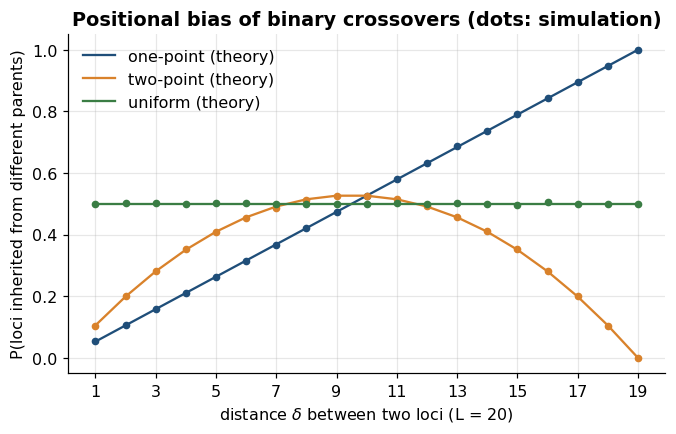

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for (name, th), col in zip(theory.items(), PALETTE.values()):
    ax.plot(deltas, th, "-", color=col, label=f"{name} (theory)")
    ax.plot(deltas, emp_dis[name], "o", color=col, ms=4)
ax.set(xlabel=r"distance $\delta$ between two loci (L = 20)", ylabel="P(loci inherited from different parents)",
       title="Positional bias of binary crossovers (dots: simulation)")
ax.set_xticks(np.arange(1, L, 2))
ax.legend()
savefig("w4_positional_bias.png"); plt.show()

## 3. Real-valued representation

For $x \in \mathbb{R}^d$ in a box $[\ell, u]^d$, operators act coordinatewise (except Gaussian mutation, which is
isotropic):

* **Arithmetic / intermediate** (Michalewicz 1992; Mühlenbein & Schlierkamp-Voosen 1993):
  $c = \lambda p_1 + (1-\lambda) p_2$, $\lambda \sim U[0,1]$ (whole arithmetic: one $\lambda$ for all coordinates).
* **BLX-$\alpha$** (Eshelman & Schaffer 1993): $c_i \sim U[\min_i - \alpha I_i,\ \max_i + \alpha I_i]$ with
  $I_i = |p_{1i} - p_{2i}|$; the recommended $\alpha = 0.5$ lets children land outside the parents' hull.
* **SBX, simulated binary crossover** (Deb & Agrawal 1995): designed so that the *spread factor*
  $\beta = |c_1 - c_2| / |p_1 - p_2|$ has the density

$$p(\beta) = \begin{cases} \tfrac12(\eta+1)\beta^{\eta}, & 0 \le \beta \le 1,\\ \tfrac12(\eta+1)\beta^{-(\eta+2)}, & \beta \gt 1,\end{cases}$$

  which mimics the spread of single-point crossover on binary-coded reals. Sampling by inversion: $u \sim U[0,1)$,
  $\beta = (2u)^{1/(\eta+1)}$ if $u \le 1/2$, else $\beta = (2(1-u))^{-1/(\eta+1)}$; then
  $c_{1,2} = \tfrac12\big[(1\pm\beta)p_1 + (1\mp\beta)p_2\big]$. Large $\eta$ = children close to parents.
* **Polynomial mutation** (Deb & Agrawal 1995; Deb & Goyal 1996): $y = x + \bar\delta\,(u - \ell)$ with
  $\bar\delta$ of density $\tfrac12(\eta_m+1)(1-|\bar\delta|)^{\eta_m}$ on $[-1,1]$.
* **Gaussian mutation**: $y = x + \sigma z$, $z \sim N(0, I)$ — the operator of evolution strategies
  (Rechenberg 1973; Schwefel 1977), central to Week 6 (CMA-ES).

**Variance transfer.** Let parents be i.i.d. with variance $\sigma^2$ per coordinate, $m = (p_1+p_2)/2$,
$I = |p_1 - p_2|$, so $\mathrm{Var}(m) = \sigma^2/2$ and $E[I^2] = 2\sigma^2$. Then

* BLX-$\alpha$: $c = m + $ uniform noise of width $(1+2\alpha)I$ $\Rightarrow$
  $\mathrm{Var}(c) = \sigma^2\left[\tfrac12 + \tfrac{(1+2\alpha)^2}{6}\right]$, which equals $\sigma^2$ iff
  $\alpha = (\sqrt3 - 1)/2 \approx 0.366$. With $\alpha = 0.5$ the population *expands* by $7/6$ per generation in the
  absence of selection; $\alpha = 0$ contracts by $2/3$.
* SBX: $c = m \pm \beta I/2$ $\Rightarrow$ $\mathrm{Var}(c) = \sigma^2\,\tfrac{1 + E[\beta^2]}{2}$ with
  $E[\beta^2] = \tfrac{\eta+1}{2}\left(\tfrac{1}{\eta+3} + \tfrac{1}{\eta-1}\right)$ for $\eta \gt 1$. Since
  $(\eta+1)^2 \gt (\eta+3)(\eta-1)$, $E[\beta^2] \gt 1$ always: SBX is mildly variance-*expanding*
  (factor $1.4$ at $\eta = 2$, $1.005$ at $\eta = 20$).
* Whole arithmetic: $\mathrm{Var}(c) = E[\lambda^2 + (1-\lambda)^2]\sigma^2 = \tfrac23\sigma^2$ — contracting.

Contracting operators combined with selection lose diversity geometrically; this is one formal reason why
plain arithmetic crossover converges prematurely and why BLX-0.5 and SBX were designed to spread.

In [5]:
def arithmetic(p1, p2, rng):
    lam = rng.random((p1.shape[0], 1))
    return lam * p1 + (1 - lam) * p2


def blx(p1, p2, rng, alpha=0.5):
    lo, hi = np.minimum(p1, p2), np.maximum(p1, p2)
    I = hi - lo
    return rng.uniform(lo - alpha * I, hi + alpha * I)


def sbx_beta(shape, rng, eta):
    u = rng.random(shape)
    return np.where(u <= 0.5, (2 * u) ** (1 / (eta + 1)), (2 * (1 - u)) ** (-1 / (eta + 1)))


def sbx(p1, p2, rng, eta=15.0):
    """Simulated binary crossover (unbounded form). Returns both children."""
    beta = sbx_beta(p1.shape, rng, eta)
    c1 = 0.5 * ((1 + beta) * p1 + (1 - beta) * p2)
    c2 = 0.5 * ((1 - beta) * p1 + (1 + beta) * p2)
    return c1, c2


def poly_delta(shape, rng, eta):
    u = rng.random(shape)
    return np.where(u < 0.5, (2 * u) ** (1 / (eta + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta + 1)))


def polynomial_mutation(x, rng, lower, upper, eta=20.0, pm=None):
    pm = 1.0 / x.shape[-1] if pm is None else pm
    mask = rng.random(x.shape) < pm
    return np.clip(x + mask * poly_delta(x.shape, rng, eta) * (upper - lower), lower, upper)


def gaussian_mutation(x, rng, sigma):
    return x + sigma * rng.standard_normal(x.shape)

### 3.1 Validation of SBX and polynomial mutation against their densities

We recover $\beta$ from the children ($\beta = |c_1 - c_2|/|p_1 - p_2|$ — this goes through the crossover formula,
not the sampler) and run a Kolmogorov–Smirnov test against the analytic CDF
$F(\beta) = \tfrac12\beta^{\eta+1}$ ($\beta \le 1$), $1 - \tfrac12\beta^{-(\eta+1)}$ ($\beta \gt 1$). For polynomial
mutation the CDF is $\tfrac12(1+\bar\delta)^{\eta+1}$ on $[-1,0]$ and $1-\tfrac12(1-\bar\delta)^{\eta+1}$ on $[0,1]$,
with mean absolute step $E|\bar\delta| = 1/(\eta+2)$.

In [6]:
def sbx_cdf(b, eta):
    b = np.asarray(b, float)
    return np.where(b <= 1, 0.5 * b ** (eta + 1), 1 - 0.5 * b ** (-(eta + 1)))

def sbx_pdf(b, eta):
    return np.where(b <= 1, 0.5 * (eta + 1) * b**eta, 0.5 * (eta + 1) * b ** (-(eta + 2)))

Ns = 50_000
P1 = rng.uniform(-5, 5, (Ns, 1)); P2 = rng.uniform(-5, 5, (Ns, 1))
beta_rec = {}
for eta in (2.0, 5.0, 20.0):
    c1, c2 = sbx(P1, P2, rng, eta)
    b = (np.abs(c1 - c2) / np.abs(P1 - P2)).ravel()
    beta_rec[eta] = b
    ks = stats.kstest(b, lambda t: sbx_cdf(t, eta))
    check_true(ks.pvalue > 0.01, f"SBX eta={eta:>4}: spread factor ~ analytic density (KS D={ks.statistic:.4f}, p={ks.pvalue:.2f})")
    check_close(np.abs((c1 + c2) / 2 - (P1 + P2) / 2).max(), 0.0, f"SBX eta={eta:>4}: children mean = parents mean", atol=1e-9)
for eta in (5.0, 20.0, 100.0):
    dl = poly_delta(Ns, rng, eta)
    ks = stats.kstest(dl, lambda t: np.where(t <= 0, 0.5 * (1 + t) ** (eta + 1), 1 - 0.5 * (1 - t) ** (eta + 1)))
    check_true(ks.pvalue > 0.01, f"polynomial mutation eta={eta:>5}: delta ~ analytic density (p={ks.pvalue:.2f})")
    check_close(np.abs(dl).mean(), 1 / (eta + 2), f"polynomial mutation eta={eta:>5}: E|delta| = 1/(eta+2)", atol=4e-3 / np.sqrt(eta))

[PASS] SBX eta= 2.0: spread factor ~ analytic density (KS D=0.0033, p=0.63)
[PASS] SBX eta= 2.0: children mean = parents mean: got 0.0, expected 0.0
[PASS] SBX eta= 5.0: spread factor ~ analytic density (KS D=0.0030, p=0.75)
[PASS] SBX eta= 5.0: children mean = parents mean: got 0.0, expected 0.0
[PASS] SBX eta=20.0: spread factor ~ analytic density (KS D=0.0038, p=0.48)
[PASS] SBX eta=20.0: children mean = parents mean: got 0.0, expected 0.0
[PASS] polynomial mutation eta=  5.0: delta ~ analytic density (p=0.79)
[PASS] polynomial mutation eta=  5.0: E|delta| = 1/(eta+2): got 0.142807, expected 0.142857
[PASS] polynomial mutation eta= 20.0: delta ~ analytic density (p=0.63)
[PASS] polynomial mutation eta= 20.0: E|delta| = 1/(eta+2): got 0.045162, expected 0.045455
[PASS] polynomial mutation eta=100.0: delta ~ analytic density (p=0.96)
[PASS] polynomial mutation eta=100.0: E|delta| = 1/(eta+2): got 0.00981, expected 0.009804


### 3.2 Validation of the variance-transfer formulas

Parents are drawn i.i.d. from $N(0,1)$ (so $\sigma^2 = 1$) and we compare the variance of $4\times10^5$ children with
the derived factors. The four formulas were derived above by hand; the simulation only applies the operators.

In [7]:
Nv = 400_000
Q1, Q2 = rng.standard_normal((Nv, 1)), rng.standard_normal((Nv, 1))
Eb2 = lambda eta: (eta + 1) / 2 * (1 / (eta + 3) + 1 / (eta - 1))
var_rows = [
    ("whole arithmetic", arithmetic(Q1, Q2, rng).var(), 2 / 3),
    ("BLX-0.0", blx(Q1, Q2, rng, 0.0).var(), 0.5 + 1 / 6),
    ("BLX-0.366", blx(Q1, Q2, rng, (np.sqrt(3) - 1) / 2).var(), 1.0),
    ("BLX-0.5", blx(Q1, Q2, rng, 0.5).var(), 0.5 + 4 / 6),
    ("SBX eta=2", sbx(Q1, Q2, rng, 2.0)[0].var(), (1 + Eb2(2.0)) / 2),
    ("SBX eta=20", sbx(Q1, Q2, rng, 20.0)[0].var(), (1 + Eb2(20.0)) / 2),
]
for name, v, th in var_rows:
    print(f"{name:18s} Var(child)/Var(parent): simulated {v:.4f}  theory {th:.4f}")
check_true(all(abs(v - th) < 0.02 * th for _, v, th in var_rows),
           "variance transfer of arithmetic, BLX-alpha and SBX within 2% of theory")

whole arithmetic   Var(child)/Var(parent): simulated 0.6688  theory 0.6667
BLX-0.0            Var(child)/Var(parent): simulated 0.6678  theory 0.6667
BLX-0.366          Var(child)/Var(parent): simulated 1.0015  theory 1.0000
BLX-0.5            Var(child)/Var(parent): simulated 1.1663  theory 1.1667
SBX eta=2          Var(child)/Var(parent): simulated 1.4015  theory 1.4000
SBX eta=20         Var(child)/Var(parent): simulated 1.0035  theory 1.0046
[PASS] variance transfer of arithmetic, BLX-alpha and SBX within 2% of theory


A caveat on the SBX $\eta = 2$ row: the tail $p(\beta) \propto \beta^{-4}$ has infinite fourth moment
($E[\beta^4] \lt \infty$ iff $\eta \gt 3$), so the *sample variance* of SBX children converges slowly for small
$\eta$ — occasional very distant children are part of the design, and why SBX is usually paired with bounds.

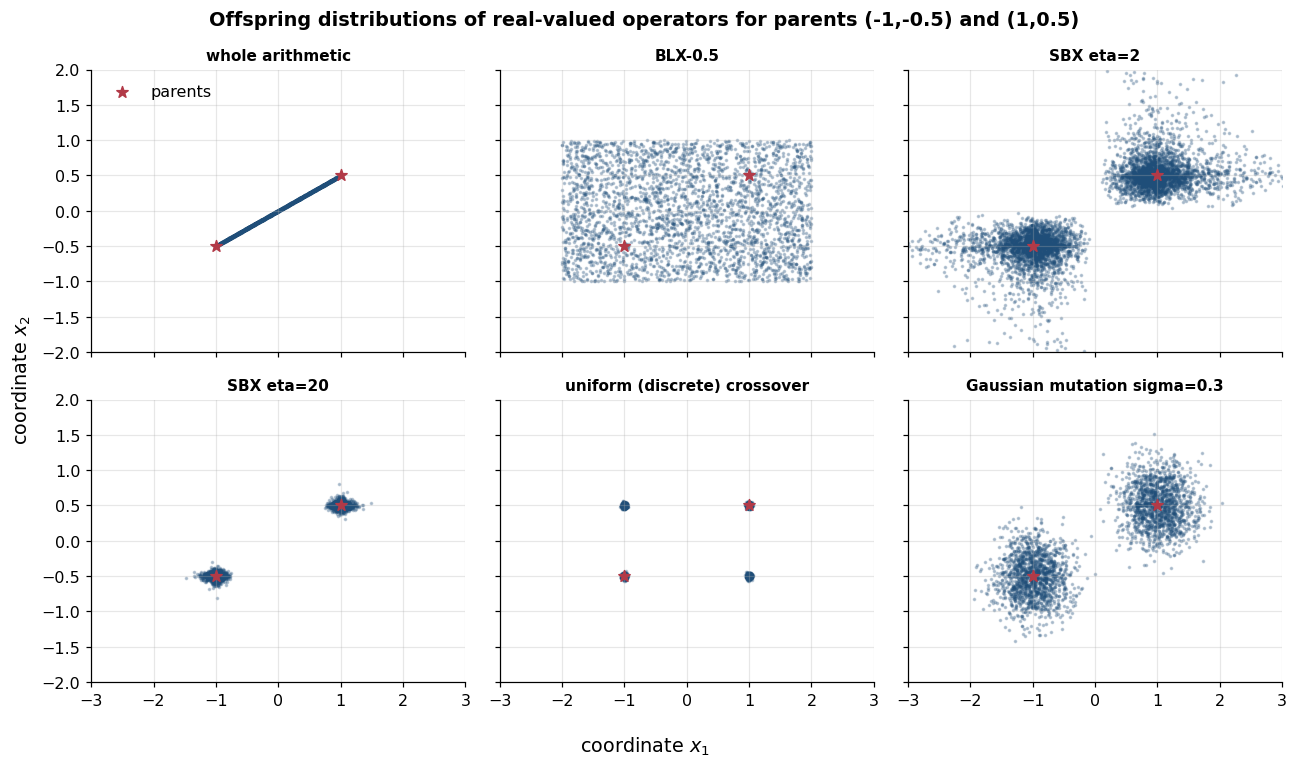

In [8]:
p1v, p2v = np.array([[-1.0, -0.5]]), np.array([[1.0, 0.5]])
K = 3000
R1, R2 = np.repeat(p1v, K, 0), np.repeat(p2v, K, 0)
panels = {
    "whole arithmetic": arithmetic(R1, R2, rng),
    "BLX-0.5": blx(R1, R2, rng, 0.5),
    "SBX eta=2": np.concatenate(sbx(R1, R2, rng, 2.0)),
    "SBX eta=20": np.concatenate(sbx(R1, R2, rng, 20.0)),
    "uniform (discrete) crossover": np.where(rng.random((K, 2)) < 0.5, R1, R2) + 0.02 * rng.standard_normal((K, 2)),
    "Gaussian mutation sigma=0.3": gaussian_mutation(np.concatenate([R1[: K // 2], R2[: K // 2]]), rng, 0.3),
}
fig, axs = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
for ax, (name, C) in zip(axs.ravel(), panels.items()):
    ax.scatter(C[:, 0], C[:, 1], s=2, alpha=0.25, color=PALETTE["blue"])
    ax.scatter([-1, 1], [-0.5, 0.5], s=60, marker="*", color=PALETTE["red"], zorder=3, label="parents")
    ax.set_title(name, fontsize=10); ax.set_xlim(-3, 3); ax.set_ylim(-2, 2)
axs[0, 0].legend(loc="upper left")
fig.suptitle("Offspring distributions of real-valued operators for parents (-1,-0.5) and (1,0.5)", weight="bold")
fig.supxlabel("coordinate $x_1$"); fig.supylabel("coordinate $x_2$")
fig.tight_layout()
savefig("w4_offspring_distributions.png"); plt.show()

The panels make the *exploration–exploitation profile* of each operator visible: arithmetic crossover samples only
the segment between the parents (pure interpolation, contracting); BLX-0.5 fills an axis-aligned box that extends
beyond the parents; SBX concentrates mass near each parent, with $\eta$ controlling the concentration, and is
coordinatewise — so in 2-D its children lie in a cross-like pattern aligned with the axes (the operator is not
rotation-invariant, a weakness revisited with CMA-ES in Week 6); discrete crossover only produces the corners of
the box; Gaussian mutation is isotropic around each parent.

## 4. Permutation representation

For the TSP, a genotype is a permutation $\pi$ of the cities and the meaningful units are **adjacencies** (the
undirected edges $\lbrace\pi_i, \pi_{i+1}\rbrace$), not absolute positions. Naive $n$-point crossover produces
duplicates, so dedicated operators exist:

| Operator | Origin | Preserves |
|---|---|---|
| PMX, partially mapped | Goldberg & Lingle 1985 | a segment of $p_1$ at the same positions; rest from $p_2$ positions via the segment mapping |
| OX, order crossover | Davis 1985 | a segment of $p_1$ at the same positions; the *relative order* of the remaining cities from $p_2$ |
| CX, cycle crossover | Oliver, Smith & Holland 1987 | every city at the absolute position it has in $p_1$ or in $p_2$ |
| ERX, edge recombination | Whitley, Starkweather & Fuquay 1989 | adjacencies: the child is built by walking the union edge graph, preferring cities with few remaining neighbours |

```text
ERX(p1, p2):
    A[c] <- union of neighbours of city c in p1 and p2  (2..4 cities)
    c <- first city of p1 (or of p2, at random);  child <- [c]
    while |child| < n:
        remove c from every list A[.]
        if A[c] is non-empty: c <- argmin over A[c] of |A[.]|, ties at random
        else:                 c <- random unvisited city            # a "foreign" edge
        append c to child
```

**Heritability** $h$ = fraction of the child's $n$ undirected edges that occur in $p_1$ or $p_2$. For a random
permutation (no inheritance at all), each edge is uniform over the $\binom n2$ possible ones, so
$E[h] = |E(p_1) \cup E(p_2)| / \binom n2$ — the baseline that tells us how much structure an operator transmits.

In [9]:
def pmx(p1, p2, rng):
    n = len(p1)
    a, b = np.sort(rng.choice(n + 1, 2, replace=False))
    child = np.full(n, -1)
    child[a:b] = p1[a:b]
    inseg = np.zeros(n, bool); inseg[p1[a:b]] = True
    pos2 = np.empty(n, int); pos2[p2] = np.arange(n)
    for i in range(a, b):
        c = p2[i]
        if not inseg[c]:
            j = i
            while a <= j < b:                     # follow the mapping p1[j] -> its position in p2
                j = pos2[p1[j]]
            child[j] = c
    free = child < 0
    child[free] = p2[free]
    return child


def ox(p1, p2, rng):
    n = len(p1)
    a, b = np.sort(rng.choice(n + 1, 2, replace=False))
    child = np.full(n, -1)
    child[a:b] = p1[a:b]
    inseg = np.zeros(n, bool); inseg[p1[a:b]] = True
    order = np.roll(p2, -b)                        # p2 read from position b onwards (wrapping)
    fill = order[~inseg[order]]
    slots = np.roll(np.arange(n), -b)[: n - (b - a)]
    child[slots] = fill
    return child


def cx(p1, p2, rng):
    n = len(p1)
    pos1 = np.empty(n, int); pos1[p1] = np.arange(n)
    child = np.full(n, -1)
    take_p1 = True
    for start in range(n):
        if child[start] >= 0:
            continue
        i = start
        while child[i] < 0:                        # walk one cycle
            child[i] = p1[i] if take_p1 else p2[i]
            i = pos1[p2[i]]
        take_p1 = not take_p1
    return child


def erx(p1, p2, rng):
    """Edge recombination (Whitley, Starkweather & Fuquay 1989)."""
    n = len(p1)
    adj = [set() for _ in range(n)]
    for p in (p1.tolist(), p2.tolist()):
        for i in range(n):
            a, b = p[i], p[i - 1]
            adj[a].add(b); adj[b].add(a)
    c = int(p1[0] if rng.random() < 0.5 else p2[0])
    child, unvisited = [c], set(range(n)) - {c}
    u = rng.random(n)                              # pre-drawn tie-breaking / restart randomness
    for step in range(1, n):
        for nb in adj[c]:
            adj[nb].discard(c)
        cand = adj[c]
        if cand:
            dmin = min(len(adj[x]) for x in cand)
            ties = [x for x in cand if len(adj[x]) == dmin]
            c = ties[int(u[step] * len(ties))]
        else:                                      # dead end: a foreign edge is unavoidable
            rest = sorted(unvisited)
            c = rest[int(u[step] * len(rest))]
        child.append(c); unvisited.discard(c)
    return np.array(child)


def edges(p):
    q = np.roll(p, -1)
    return set(zip(np.minimum(p, q).tolist(), np.maximum(p, q).tolist()))


def heritability(child, p1, p2):
    return len(edges(child) & (edges(p1) | edges(p2))) / len(child)

### 4.1 Validity and defining properties

Over 2,000 random parent pairs ($n = 30$) we check that every child is a permutation and that each operator has
the property it is defined to have (these are properties of the *output*, checked independently of how the code
builds it).

In [10]:
def rand_perm_x(p1, p2, rng):
    return rng.permutation(len(p1))

ops = {"PMX": pmx, "OX": ox, "CX": cx, "ERX": erx, "random permutation": rand_perm_x}
n_c, trials = 30, 2000
valid = {k: True for k in ops}
cx_positional = True
ox_order = True
herit = {k: [] for k in ops}
baseline = []
for _ in range(trials):
    p1, p2 = rng.permutation(n_c), rng.permutation(n_c)
    for name, op in ops.items():
        c = op(p1, p2, rng)
        valid[name] &= bool(np.array_equal(np.sort(c), np.arange(n_c)))
        herit[name].append(heritability(c, p1, p2))
        if name == "CX":
            cx_positional &= bool(np.all((c == p1) | (c == p2)))
        if name == "OX":
            # the cities that differ in position from p1 must appear in the same cyclic relative order as in p2
            keep = c != p1
            sub = c[keep]
            pos2 = np.empty(n_c, int); pos2[p2] = np.arange(n_c)
            r = pos2[sub]
            if len(r) > 1:
                ox_order &= bool(np.sum(np.diff(np.r_[r, r[0]]) < 0) <= 1)   # one cyclic wrap-around
    baseline.append(len(edges(p1) | edges(p2)) / (n_c * (n_c - 1) / 2))
for name in ops:
    check_true(valid[name], f"{name:18s} always returns a valid permutation")
check_true(cx_positional, "CX: every city sits at its position in p1 or in p2")
check_true(ox_order, "OX: the non-segment cities keep p2's cyclic relative order")
check_close(np.mean(herit["random permutation"]), np.mean(baseline),
            "random-permutation heritability = |E1 u E2| / C(n,2)", atol=0.006)
print(f"\n{'operator':18s} heritability  mean  [min, max]")
for name in ops:
    h = np.array(herit[name])
    print(f"{name:18s}             {h.mean():.3f} [{h.min():.3f}, {h.max():.3f}]")

[PASS] PMX                always returns a valid permutation
[PASS] OX                 always returns a valid permutation
[PASS] CX                 always returns a valid permutation
[PASS] ERX                always returns a valid permutation
[PASS] random permutation always returns a valid permutation
[PASS] CX: every city sits at its position in p1 or in p2
[PASS] OX: the non-segment cities keep p2's cyclic relative order
[PASS] random-permutation heritability = |E1 u E2| / C(n,2): got 0.1333, expected 0.133133

operator           heritability  mean  [min, max]
PMX                            0.725 [0.467, 1.000]
OX                             0.806 [0.600, 1.000]
CX                             0.712 [0.267, 1.000]
ERX                            0.960 [0.833, 1.000]
random permutation             0.133 [0.000, 0.400]


### 4.2 Heritability near convergence

Random parents are the situation at generation 0. Late in a run parents are *similar*; we emulate this with
$p_2$ = $p_1$ after $k$ random inversions (2-opt moves) and measure the same quantity.

In [11]:
def inversion(p, rng):
    """Reverse a random segment: the 2-opt move, changes exactly two edges."""
    i, j = np.sort(rng.choice(len(p), 2, replace=False))
    q = p.copy(); q[i:j + 1] = q[i:j + 1][::-1]
    return q

near = {}
for k in (1, 4, 16):
    hk = {name: [] for name in ("PMX", "OX", "CX", "ERX")}
    for _ in range(400):
        p1 = rng.permutation(n_c); p2 = p1.copy()
        for _ in range(k):
            p2 = inversion(p2, rng)
        for name in hk:
            hk[name].append(heritability(ops[name](p1, p2, rng), p1, p2))
    near[k] = {name: np.mean(v) for name, v in hk.items()}
print("heritability when p2 = p1 + k random inversions (n = 30)")
print(f"{'k':>4s} " + " ".join(f"{name:>7s}" for name in ("PMX", "OX", "CX", "ERX")))
for k, row in near.items():
    print(f"{k:4d} " + " ".join(f"{row[name]:7.3f}" for name in ("PMX", "OX", "CX", "ERX")))
check_true(all(near[k]["ERX"] >= max(near[k].values()) - 1e-12 for k in near), "ERX has the highest heritability at every k")

heritability when p2 = p1 + k random inversions (n = 30)
   k     PMX      OX      CX     ERX
   1   0.977   0.957   0.697   0.998
   4   0.890   0.908   0.617   0.973
  16   0.773   0.841   0.703   0.953
[PASS] ERX has the highest heritability at every k


ERX transmits almost all edges in both regimes (foreign edges appear only when the walk hits a dead end). OX
preserves *relative order* and PMX preserves *absolute positions*; for random parents OX transmits more edges,
for very similar parents (same "frame") the two are close. CX, which only moves whole position-cycles, has the
lowest heritability: with similar parents it often swaps a long cycle and breaks many adjacencies. Because the TSP
cost is a sum over edges, we expect edge-transmitting operators to do better — we now test that.

## 5. Heritability and TSP performance at an equal budget

GA: population $50$, binary tournament, crossover probability $0.9$, 1-elitism, budget $B = 6{,}000$ tour
evaluations, 6 seeds, a 30-city random Euclidean instance. We run each crossover in two regimes:

* **crossover only** ($p_{\text{mut}} = 0$), which isolates what the operator itself can do — the protocol of the
  classic comparison of Starkweather et al. (1991);
* **with inversion mutation** ($p_{\text{mut}} = 0.3$ per child), the usual practical setting;

plus a **mutation-only** baseline (no crossover, inversion on every child). First, a sanity check on a 10-city
instance whose optimum is known exactly from Held–Karp (3,000 evaluations, 4 seeds).

In [12]:
def ga_tsp(D, xover, rng, N=50, budget=6_000, pc=0.9, pmut=0.3, k=2):
    """Generational GA with k-tournament, crossover, inversion mutation and 1-elitism (minimisation)."""
    n = len(D)
    P = np.array([rng.permutation(n) for _ in range(N)])
    cost = lambda T: D[T, np.roll(T, -1, axis=1)].sum(1)
    f = cost(P); evals = N
    tr_e, tr_b = [evals], [f.min()]
    while evals + N <= budget:
        T = rng.integers(0, N, (N, 2, k))
        win = np.take_along_axis(T, np.argmin(f[T], axis=2)[..., None], 2)[..., 0]   # (N, 2) parent indices
        do_x, do_m = rng.random(N) < pc, rng.random(N) < pmut
        C = np.empty_like(P)
        for i in range(N):
            a, b = P[win[i, 0]], P[win[i, 1]]
            c = xover(a, b, rng) if do_x[i] else a.copy()
            C[i] = inversion(c, rng) if do_m[i] else c
        fc = cost(C); evals += N
        if f.min() < fc.min():
            w = np.argmax(fc); C[w] = P[np.argmin(f)]; fc[w] = f.min()
        P, f = C, fc
        tr_e.append(evals); tr_b.append(min(tr_b[-1], f.min()))
    return np.array(tr_e), np.array(tr_b)


pts10, D10 = random_euclidean_tsp(10, np.random.default_rng(7))
opt10, _ = held_karp(D10)
for name in ("PMX", "OX", "CX", "ERX"):
    bests = np.array([ga_tsp(D10, ops[name], np.random.default_rng(s), budget=3_000)[1][-1] for s in range(4)])
    hits = int(np.sum(np.isclose(bests, opt10, atol=1e-9)))
    check_true(hits >= 1 and np.all(bests >= opt10 - 1e-9),
               f"GA with {name}: never below the Held-Karp optimum {opt10:.4f}, reaches it in {hits}/4 seeds")

[PASS] GA with PMX: never below the Held-Karp optimum 3.1341, reaches it in 4/4 seeds


[PASS] GA with OX: never below the Held-Karp optimum 3.1341, reaches it in 1/4 seeds


[PASS] GA with CX: never below the Held-Karp optimum 3.1341, reaches it in 4/4 seeds


[PASS] GA with ERX: never below the Held-Karp optimum 3.1341, reaches it in 4/4 seeds


In [13]:
pts, D = random_euclidean_tsp(30, np.random.default_rng(42))
SEEDS, BUD = 6, 6_000
XO = ("PMX", "OX", "CX", "ERX")
tsp_runs = {}
for pm in (0.0, 0.3):
    for name in XO:
        tsp_runs[(name, pm)] = [ga_tsp(D, ops[name], np.random.default_rng(10 + s), budget=BUD, pmut=pm)
                                for s in range(SEEDS)]
tsp_runs[("mutation only", 1.0)] = [ga_tsp(D, ops["OX"], np.random.default_rng(10 + s), budget=BUD, pc=0.0, pmut=1.0)
                                    for s in range(SEEDS)]
final = {key: np.array([r[1][-1] for r in v]) for key, v in tsp_runs.items()}
print(f"{'operator':16s} {'p_mut':>5s}   final tour length: median [IQR]")
for (name, pm), v in final.items():
    q1, q3 = np.percentile(v, [25, 75])
    print(f"{name:16s} {pm:5.1f}   {np.median(v):.3f} [{q1:.3f}, {q3:.3f}]")

operator         p_mut   final tour length: median [IQR]
PMX                0.0   8.378 [7.585, 8.942]
OX                 0.0   5.729 [5.604, 6.020]
CX                 0.0   11.222 [11.122, 11.484]
ERX                0.0   5.941 [5.638, 6.286]
PMX                0.3   6.170 [5.976, 6.522]
OX                 0.3   7.648 [7.100, 7.813]
CX                 0.3   6.712 [6.281, 7.218]
ERX                0.3   4.859 [4.841, 4.866]
mutation only      1.0   6.253 [6.197, 6.632]


The checks below are paired per-seed comparisons (both runs of a seed see the same instance and the same initial
population) with a one-sided Wilcoxon signed-rank test (`scipy.stats.wilcoxon`). With 6 seeds the smallest
attainable one-sided $p$-value is $1/64 \approx 0.016$, reached only if the ordering holds on every seed.

In [14]:
for pm in (0.0, 0.3):
    w = stats.wilcoxon(final[("ERX", pm)], final[("CX", pm)], alternative="less")
    check_true(w.pvalue < 0.05, f"p_mut={pm}: ERX (highest heritability) beats CX (lowest) — Wilcoxon p = {w.pvalue:.3f}")
w = stats.wilcoxon(final[("ERX", 0.3)], final[("mutation only", 1.0)], alternative="less")
check_true(w.pvalue < 0.05, f"ERX GA beats the mutation-only baseline — Wilcoxon p = {w.pvalue:.3f}")

[PASS] p_mut=0.0: ERX (highest heritability) beats CX (lowest) — Wilcoxon p = 0.016
[PASS] p_mut=0.3: ERX (highest heritability) beats CX (lowest) — Wilcoxon p = 0.016
[PASS] ERX GA beats the mutation-only baseline — Wilcoxon p = 0.016


**What the table says** (6 seeds, 6,000 evaluations):

* **Heritability matters.** ERX, the operator that transmits edges best, is the best with mutation (median
  $4.86$, with a very tight IQR) and beats CX, the least heritable operator, on every seed in both regimes.
* **Heritability is not sufficient: something must also create edges.** Without mutation, PMX and CX stagnate
  (medians $8.4$ and $11.2$): an operator that only recombines existing adjacencies cannot discover an edge that
  no individual carries. OX (median $5.73$) and ERX ($5.94$) do well without mutation because each also introduces a
  few *foreign* edges — an implicit mutation. For OX they arise at the two ends of the copied segment and
  wherever $p_2$'s order is spliced by deleting the segment cities (the neighbours of a deleted run become
  adjacent); for ERX they arise only at dead ends of the edge walk.
* **Too much disruption hurts.** Adding inversion mutation helps PMX, CX and ERX but *hurts* OX (median $7.65$):
  OX's own foreign edges plus a 2-opt move on 30% of the children exceed what binary-tournament selection can
  repair — an instance of Eigen's *error threshold* idea, and a reminder that operator and mutation rate must be
  tuned jointly.

The practical lesson: design variation operators around the units the objective is made of (here edges), and
control the *total* rate at which new units are introduced.

A caveat on the baseline: "mutation only" here is the same *generational* GA ($N = 50$) without crossover. An
elitist $(\mu+\lambda)$ EA with inversion mutation and a small population is a much stronger mutation-only
baseline on a 30-city instance at this budget (Exercise 6); crossover pays off mainly when it recombines good,
diverse parents, as in the memetic algorithms of the Lab.

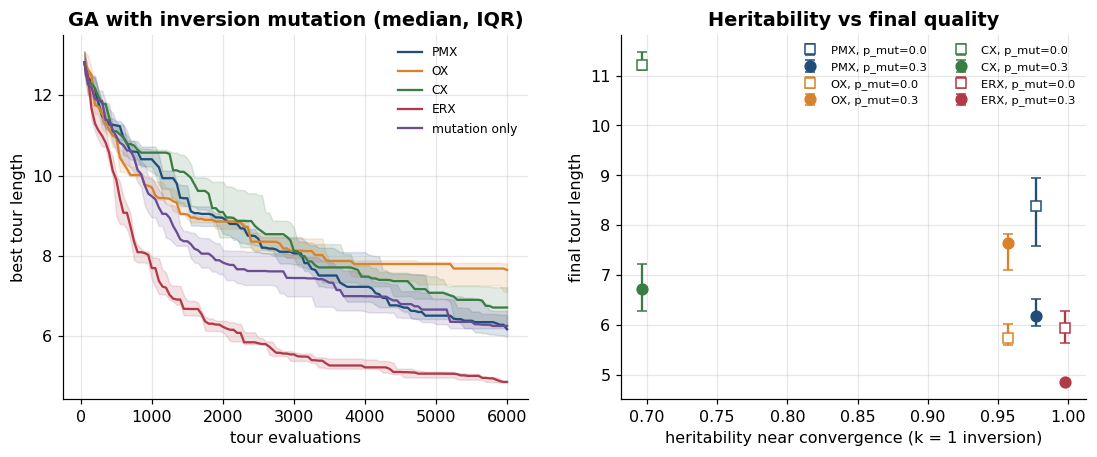

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
grid = np.arange(50, BUD + 1, 50)
cols = dict(zip(XO + ("mutation only",), PALETTE.values()))
for (name, pm), rr in tsp_runs.items():
    if pm == 0.0:
        continue
    Y = np.array([best_so_far_on_grid(r[0], r[1], grid) for r in rr])
    ax[0].plot(grid, np.median(Y, 0), color=cols[name], label=name)
    ax[0].fill_between(grid, *np.percentile(Y, [25, 75], 0), color=cols[name], alpha=0.15)
ax[0].set(xlabel="tour evaluations", ylabel="best tour length", title="GA with inversion mutation (median, IQR)")
ax[0].legend(fontsize=8)
for name in XO:
    for pm, mk in ((0.0, "s"), (0.3, "o")):
        v = final[(name, pm)]
        ax[1].errorbar(near[1][name], np.median(v), yerr=[[np.median(v) - np.percentile(v, 25)],
                       [np.percentile(v, 75) - np.median(v)]], fmt=mk, color=cols[name], capsize=3, ms=7,
                       mfc="white" if pm == 0.0 else cols[name], label=f"{name}, p_mut={pm}")
ax[1].set(xlabel="heritability near convergence (k = 1 inversion)", ylabel="final tour length",
          title="Heritability vs final quality")
ax[1].legend(fontsize=7.5, ncol=2)
savefig("w4_heritability_tsp.png"); plt.show()

## Key takeaways

- A crossover is characterised by *what it transmits*: positional linkage (one-/two-point), independent loci
  (uniform), coordinates with a controlled spread (BLX, SBX), absolute positions (PMX, CX), relative order (OX), or
  adjacencies (ERX).
- One-point crossover separates loci at distance $\delta$ with probability $\delta/(L-1)$ — a positional bias that
  makes it sensitive to gene ordering; uniform crossover has no such bias.
- Real-valued operators can be analysed by their variance transfer: whole arithmetic contracts ($2/3$), BLX-$\alpha$
  preserves variance at $\alpha = (\sqrt3-1)/2$, SBX always expands slightly ($\tfrac12(1+E[\beta^2])$).
- The SBX spread factor and the polynomial-mutation step follow their published densities exactly (KS tests pass).
- On the TSP, heritability of edges predicts success (ERX beats CX on every seed), but an operator must also
  introduce a controlled number of new edges — through its own dead ends/junctions or through mutation — and too
  much total disruption degrades search (OX with inversion mutation).

## Exercises

1. ★ Derive the probability that $k$-point crossover (with $k$ distinct cut points) separates two loci at distance
   $\delta$, and check that it reduces to the one- and two-point formulas above.
2. ★ Uniform crossover of $p_1, p_2$ (Hamming distance $d$) is followed by bit-flip mutation with rate $p$.
   Compute the exact mean and variance of $d_H(\text{child}, p_1)$ as a function of $L$, $d$ and $p$, and verify
   your formula by simulation.
3. ★★ Prove that SBX with the density $p(\beta)$ above preserves the parents' mean and compute
   $E[\beta^2]$; show that no $\eta \gt 1$ makes SBX exactly variance-preserving.
4. ★★ Implement a **bounded** SBX: sample $\beta$ from $p(\beta)$ *truncated* to the interval $[0, \beta_{\max}]$
   on which both children stay in $[\ell, u]$ (Deb's NSGA-II reference code uses a related per-child
   truncation). Derive $\beta_{\max}$, sample by inverting the truncated CDF, and
   verify with a KS test that the recovered spread factors follow the truncated density.
5. ★★ Implement Whitley's *enhanced* edge recombination (Starkweather et al. 1991), which flags edges common to
   both parents and prefers them; measure the fraction of common edges preserved compared with ERX.
6. ★★★ Add 2-opt-style *inversion* mutation to a mutation-only $(\mu+\lambda)$ scheme and compare it at an equal
   budget with the ERX GA of Section 5. When does crossover pay off on the TSP? Relate your answer to the
   heritability measurements.